# Gradient Descent

Gradient Descent is a fundamental optimization algorithm used to minimize the loss function in models during the training process. The goal is to find the optimal parameters (weights and biases) for the model that minimizes the difference between the predicted outputs and the actual targets

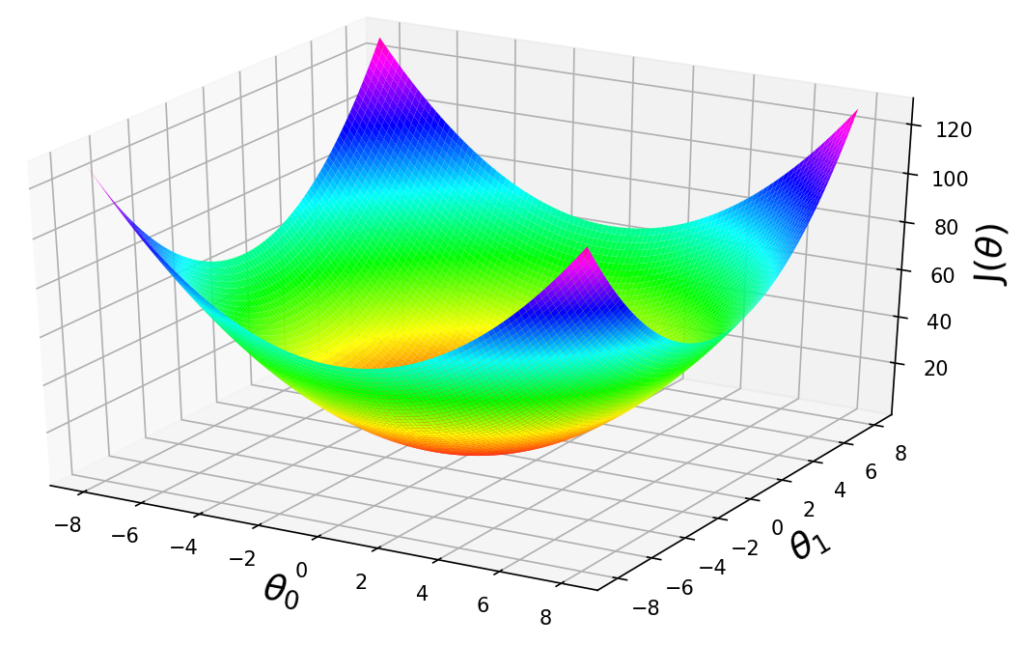

# Example

Gradient Descent is like trying to find the lowest point in a hilly terrain by taking small steps downhill. Imagine you're blindfolded and want to get to the bottom of a valley. You start at a random point and feel the ground to figure out which direction it slopes. You take small steps downhill until you can't go downhill anymore, which means you've reached the bottom.

In machine learning, the "hilly terrain" represents the loss function, which tells us how bad our model is performing. The "lowest point" is where our model performs the best. We start with random values for our model's parameters (like weights and biases), and Gradient Descent helps us adjust these parameters in the direction that reduces the loss, making our model better at predicting the correct outputs.

In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

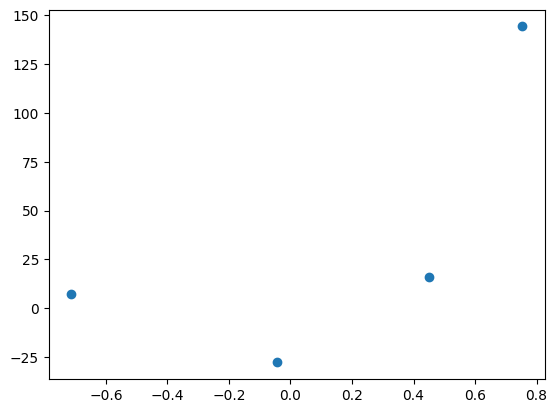

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [4]:
from sklearn.linear_model import LinearRegression    

In [5]:
reg = LinearRegression()
reg.fit(X,y)
     

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
reg.coef_#m = 78.35

array([78.35063668])

In [7]:
reg.intercept_ #b = 26.15

np.float64(26.15963284313262)

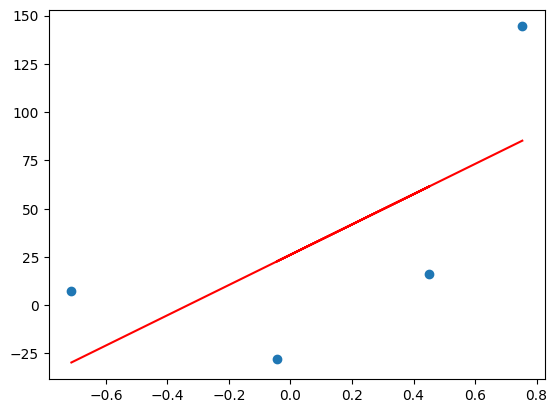

In [8]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

In [10]:
y_pred = ((78.35 * X) + 0).reshape(4)#b = 100 Y_pred = Mx + B

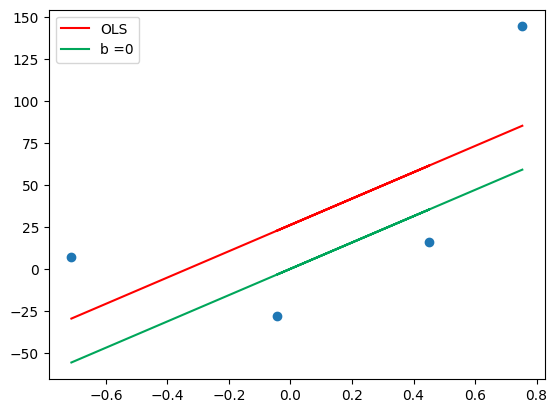

In [11]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b =0')
plt.legend()
plt.show()
     

In [12]:
m = 78.35
b = 0

loss_slope = -2 * np.sum(y - m*X.ravel() - b)# LS = -2 (y - mx -b) # MSE = (Y-mx-b)^2
loss_slope

np.float64(-209.27763408209216)

In [13]:
# Lets take learning rate = 0.1 to 0.001
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [19]:
b = b - step_size# 0 - (-20.92)
b

20.927763408209216

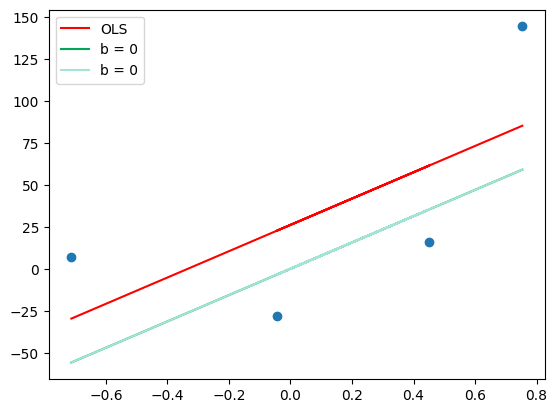

In [14]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [21]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

-41.85552681641843

In [22]:
step_size = loss_slope*lr
step_size

-4.185552681641844

In [23]:
b = b - step_size
b
     

25.11331608985106

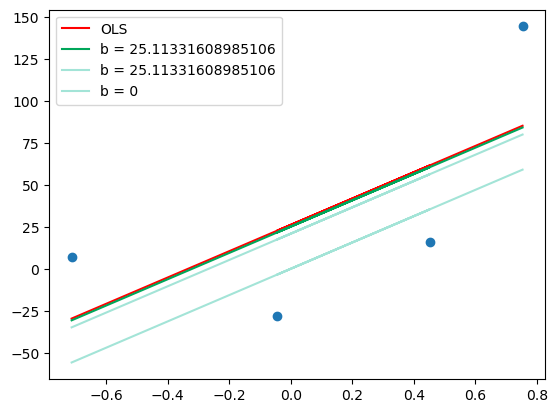

In [24]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

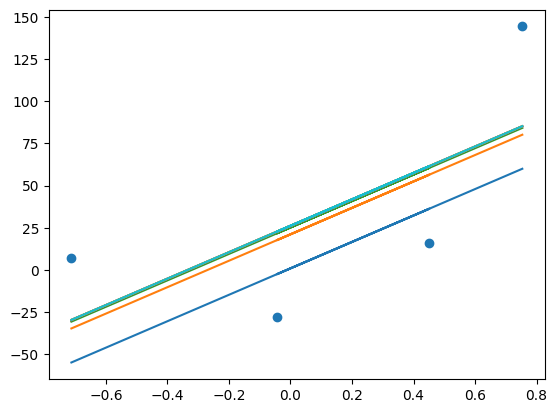

In [17]:

b = -100
m = 78.35
lr = 0.1

epochs = 10

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*X.ravel() - b)
    b = b - (lr * loss_slope)

    y_pred = m * X + b

    plt.plot(X,y_pred)

plt.scatter(X,y)

In [18]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [19]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

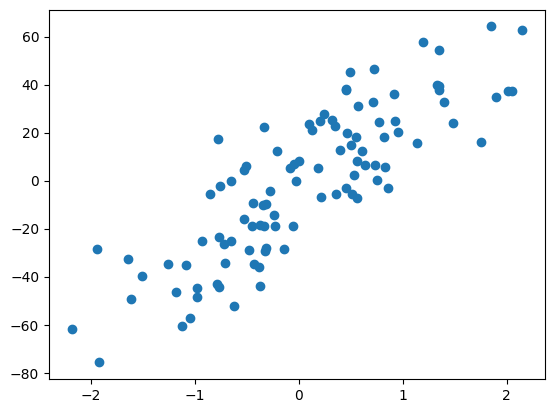

In [20]:
plt.scatter(X,y)

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
lr = LinearRegression()

In [24]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


# With M & b

In [28]:
class GDRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 1000
        self.b = -400
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,X,y):
        # calcualte the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
            print(self.b,self.m)
        #print(self.b,self.m)
        
    
    

In [39]:
gd = GDRegressor(0.01,15)

In [40]:
gd.fit(X_train,y_train)

157.6107352602428 -442.7014799543026
-60.04664396517941 258.87771268666086
13.69543648274201 -86.63293487684535
-2.5514169309603183 86.23315885281903
-6.811478533606541 -1.928501655822913
2.8887231575042467 44.05058014079584
-6.657304703427446 19.465026778313813
1.0625980269689999 32.964458352133924
-4.663267686222536 25.351358309302185
-0.6108220287591424 29.75601370584092
-3.3992199024058523 27.147705253596307
-1.5148173592886622 28.723764253920177
-2.7731745504130068 27.75526898304248
-1.9396783909660236 28.358548192406545
-2.4886627117808744 27.978739126309026


# Importance of Learning Rate

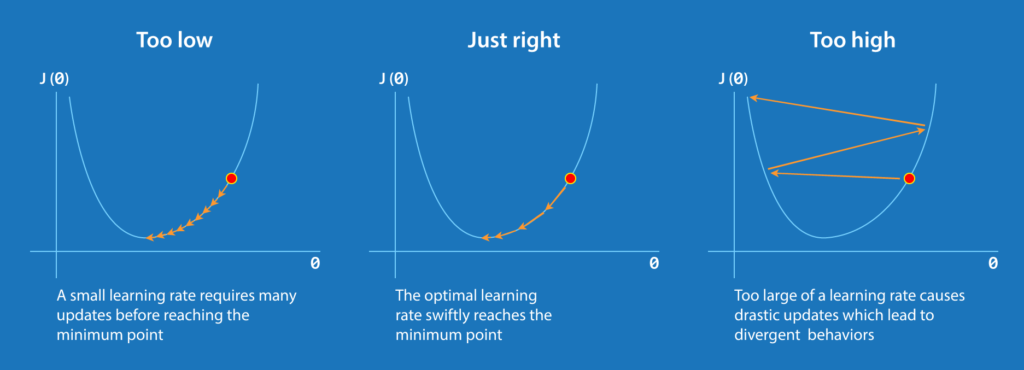

In [41]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [42]:
b = -200
m = 48
lr = 0.001
all_b = []
all_m = []
all_cost = []

epochs = 15

for i in range(epochs):
    slope_b = 0
    slope_m = 0
    cost = 0
    for j in range(X.shape[0]):
        slope_b = slope_b - 2*(y[j] - (m * X[j]) -  b)
        slope_m = slope_m - 2*(y[j] - (m * X[j]) -  b)*X[j]
        cost = cost + (y[j] - m * X[j] -b) ** 2

    b = b - (lr * slope_b)
    m = m - (lr * slope_m)
    all_b.append(b)
    all_m.append(m)
    all_cost.append(cost)

In [43]:
fig, ax = plt.subplots(figsize=(9,5))
#fig.set_tight_layout(True)

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*(-27) -150
ax.scatter(X, y)
line, = ax.plot(x_i, x_i*50 - 4, 'r-', linewidth=2)

def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*all_m[i] + all_b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=epochs, interval=500)

f = r"animation4.gif" 
writergif = animation.PillowWriter(fps=2) 
anim.save(f, writer=writergif)


<IPython.core.display.Javascript object>

# Loss Function Problem

1.Non-Convexity

2.Non-Differentiability

3.Computational Complexity

4.Difficulty in Interpreting

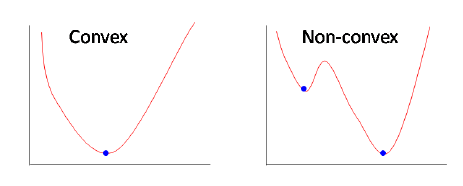

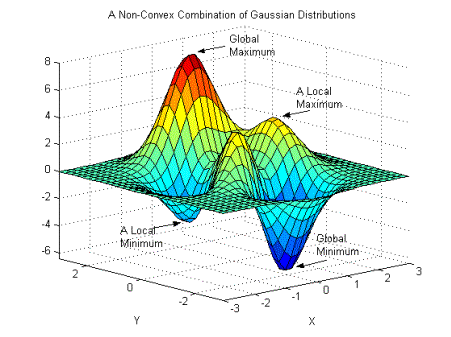

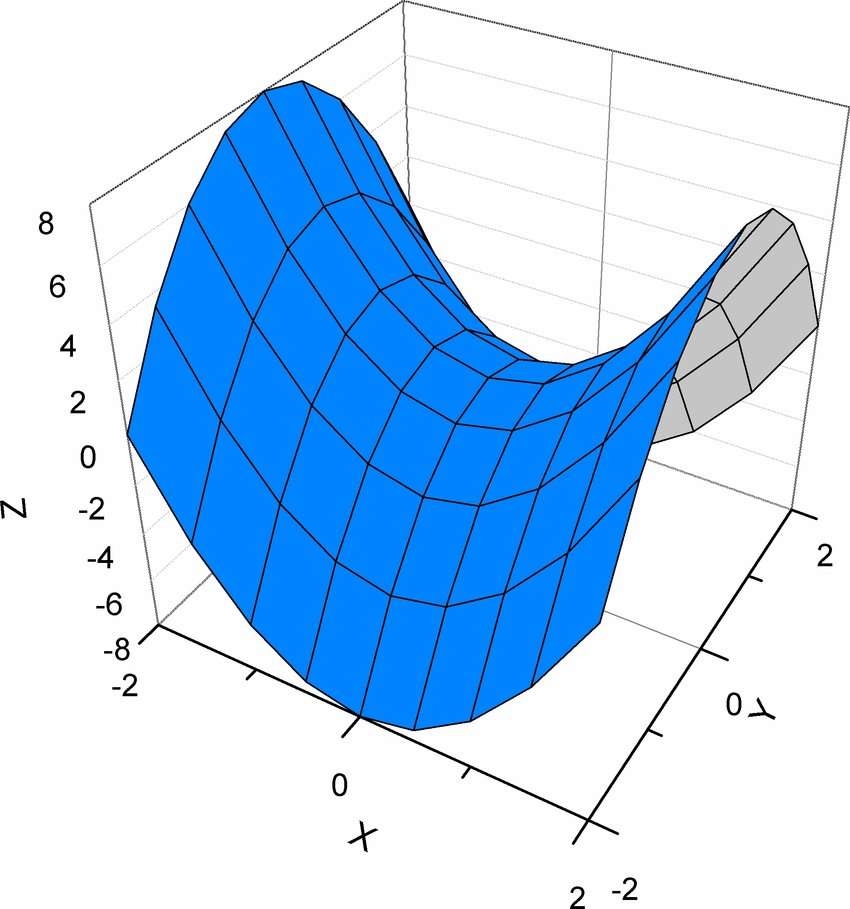